In [1]:
'''
This notebooks provides examples in how to use the lenstronomy.SimulationAPI modules in simulating (realistic) mock lenses taylored to a specific observation and instrument.

The module enables to use the astronomical magnitude conventions and can translate those into the lenstronomy core module configurations.
'''
import copy
import numpy as np
import corner
from PIL import Image
import matplotlib.pyplot as plt
import lenstronomy.Util.data_util as data_util
import lenstronomy.Util.util as util
import lenstronomy.Plots.plot_util as plot_util
from lenstronomy.Plots.plot_util import coordinate_arrows, scale_bar
from lenstronomy.SimulationAPI.sim_api import SimAPI
from lenstronomy.LightModel.Profiles.gaussian import GaussianEllipse
gauss = GaussianEllipse()
from astropy.constants import c
import astropy.units as u
import lenstronomy.Util.param_util as param_util
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.Workflow.fitting_sequence import FittingSequence
from astropy.cosmology import FlatLambdaCDM,z_at_value
cosmo = FlatLambdaCDM(H0=69.7, Om0=0.282, Ob0=0.044792699861138666)
# 定义一个函数来读取参数并返回它们作为字典
def read_parameters(file_path):
    params = {}
    with open(file_path, 'r') as file:
        for line in file:
            # 移除行尾的换行符并分割键和值
            line = line.strip()
            if line:  # 确保行不为空
                key, value_with_unit = line.split(' = ')  # 分割并去除等号两边的空格
                key = key.strip()  # 移除键的首尾空格
                value_with_unit = value_with_unit.strip()  # 移除值和单位的首尾空格
                
                # 提取值部分，并去除单位
                value = value_with_unit.split()[0]  # 分割并取值的部分
                
                # 将值转换为适当的数据类型
                if value.isdigit():  # 如果值是整数
                    params[key] = int(value)
                else:
                    # 假设值是浮点数
                    try:
                        params[key] = float(value)  # 尝试转换为float
                    except ValueError:
                        params[key] = value  # 如果转换失败，保持原样    
    return params

def Dc(z):                      # Mpc/h
    res = cosmo.comoving_distance(z).value*cosmo.h
    return res
def Dc2redshift(Dc):            # Mpc/h
    return z_at_value(cosmo.comoving_distance,Dc/cosmo.h*u.Mpc).value

/huawei/osv1/linshijie_BNU/anaconda3/envs/WL/lib/python3.11/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


# Parameters of the system

In [2]:
case = 199
# read the case.txt file
case_file = '/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/Case.txt'
case_params = read_parameters(case_file)
highdencase = case_params['highDens']

highden_file = '/huawei/osv1/linshijie_BNU/PAPER1/data/high_dens/case{:04}'.format(highdencase)+'/center_position.txt'
highden_params = read_parameters(highden_file)

maxComving = 3800               # in Mpc/h
lensnum    = 76
binL       = maxComving/lensnum
# num_lensplane = highden_params['num_lensplane']
num_lensplane    = 38
Dc_lens    = binL*(num_lensplane)+binL/2
z_lens     = Dc2redshift(Dc_lens)
z_source   = Dc2redshift(maxComving)
pixel_scale_arcsec = 0.05
piexl_scale_rad    = np.deg2rad(pixel_scale_arcsec/3600.0)

In [3]:
lens_params = read_parameters('/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/LensingParameters.txt')
theta_e = lens_params['theta_E']
phi_q,q = lens_params['phi'],lens_params['q']
print('theta_e:',theta_e)
print('phi:',phi_q)
print('q:',q)
e1, e2 = param_util.phi_q2_ellipticity(phi_q, q)
source_x, source_y = lens_params['source_x'], lens_params['source_y']

# lensing quantities
lens_model_list = ['SIE']
kwargs_lens = [{'theta_E': theta_e, 'center_x': 0.0, 'center_y': 0.0, 'e1': e1, 'e2': e2}]  # parameters of the deflector lens model

theta_e: 1.290197
phi: 2.617994
q: 0.7


# Read all the simulate data

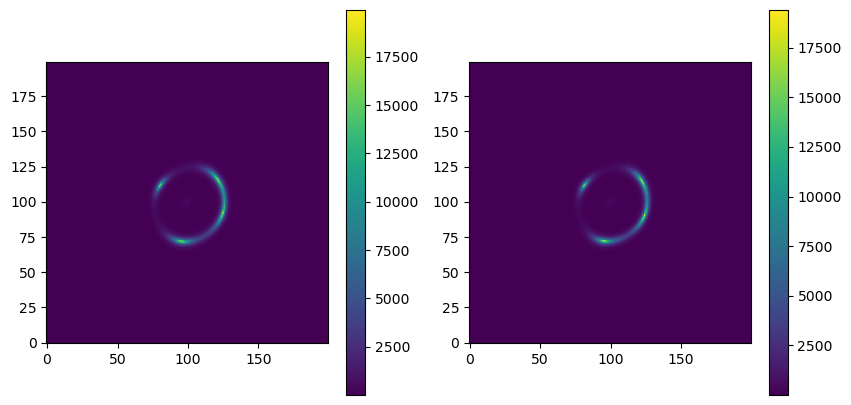

In [4]:
data_image = np.load('/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/image_data.npz')
flux_WL = data_image['flux_WL']
flux_ML = data_image['flux_ML']
fig,ax=plt.subplots(1,2,figsize=(10,5))
ax0=ax[0].imshow(flux_WL,origin='lower')
ax1=ax[1].imshow(flux_ML,origin='lower')
fig.colorbar(ax0,ax=ax[0])
fig.colorbar(ax1,ax=ax[1])


data_point = np.load('/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}'.format(case)+'/PointSources.npz')
x_oml = data_point['x_oml']
y_oml = data_point['y_oml']
mag_oml = data_point['mag_oml']
x_multilens = data_point['x_all']
y_multilens = data_point['y_all']
mag_pert = data_point['mag_pert']
mag_all  = data_point['mag_all']

In [5]:
print(x_oml,y_oml,mag_oml)
print(x_multilens,y_multilens,mag_all)

[-0.204  1.132  1.211 -0.907] [-1.388  0.739 -0.511  0.6  ] [ 4.94056862  6.39472729 -6.09950663 -2.40795834]
[-0.192  1.096  1.266 -0.95 ] [-1.399  0.783 -0.405  0.59 ] [ 5.05263248  6.62924745 -7.88401598 -2.72165814]


In [6]:
'''
Define camera and observations

As an example, we define the camera and observational settings of a LSST-like observation. We define one camera setting and three different observations corresponding th g,r,i imaging.

For the complete list of possible settings, we refer to the SimulationAPI.observation_api classes. There are pre-configured settings which approximately mimic observations from current and future instruments. Be careful using those and check whether they are sufficiently accurate for your specific science case!
'''
# Instrument setting from pre-defined configurations

#mag_min_Res = [mag_min, axis_ratio_min, position_angle_min, R_e_min, sersic_n_min, np.sum(np.array(mag_weight_by_SFR_50)<25.5) / len(mag_weight_by_SFR_50), np.sum(np.array(mag_weight_by_SFR_100)<25.5) / len(mag_weight_by_SFR_100)]
from lenstronomy.SimulationAPI.ObservationConfig.Euclid import Euclid
CSST_r = Euclid(band='VIS', psf_type='GAUSSIAN', coadd_years=6)
numPix  = len(flux_ML)
kwargs_r_band = CSST_r.kwargs_single_band()
kwargs_r_band['read_noise'] = 5.5
kwargs_r_band['pixel_scale'] = 0.05
kwargs_r_band['ccd_gain'] = 3 #需要检查
kwargs_r_band['exposure_time'] = 500
kwargs_r_band['sky_brightness'] = 22.86 #需要检查，现在是HST的F606W
kwargs_r_band['magnitude_zero_point'] = 26.48 #需要检查，现在是HST的F606W
kwargs_r_band['num_exposures'] = 1
kwargs_r_band['seeing'] = 0.001

In [7]:
'''
Define model settings

The model settings are handled by the SimulationAPI.model_api ModelAPI class. The role is to return instances of the lenstronomy LightModel, LensModel, PointSource modules according to the options chosen by the user. Currently, all other model choices are equivalent to the ones provided by LightModel, LensModel, PointSource. The current options of the class instance only describe a subset of possibilities and we refer to the specific class instances for details about all the possibilities.

For this example, we chose a single lens plane and a single source plane, elliptical Sersic profiles and an additional lensed point source.
'''
kwargs_model = {'lens_model_list': ['SIE'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],  # list of extended source models to be used
                    'point_source_model_list': ['LENSED_POSITION'],  # list of point source models to be used, here we use the lensed image 
    }
'''
Generate SimAPI instance for the different observations

Here we make an instance of the SimAPI class and execute the major tasks accessible as the interface to the ImSim core module.
'''
# here we define the numerical options used in the ImSim module. 
# Have a look at the ImageNumerics class for detailed descriptions.
# If not further specified, the default settings are used.
kwargs_numerics = {'supersampling_factor': 1, 'supersampling_convolution': False}

# return the ImSim instance. With this class instance, you can compute all the
# modelling accessible of the core modules. See class documentation and other notebooks.
sim_r = SimAPI(numpix=numPix, kwargs_single_band=kwargs_r_band, kwargs_model=kwargs_model)
imSim_r = sim_r.image_model_class(kwargs_numerics)
print(sim_r.background_noise)

0.016163900578065486


# Compare the simulated image with observational magnitude

In [8]:
'''
Brightness definitions in magnitude space

One core feature is the support of light profile amplitudes in astronomical magnitude space (at least for few selected well defined brightness profiles).

We first define all parameters in magnitude space and then use the SimAPI routine to translate the arguments into lenstronomy conventions used by the ImSim module. The second model of each light component we defined as 'INTERPOL', which sets an interpolation grid given an image. This can be used to past real galaxies as lenses or sources into lenstronomy.
'''

kwargs_source_mag_r1 = [{'magnitude': 20.8, 'R_sersic': 0.1, 'n_sersic': 1, 
                       'e1': -0.1, 'e2': 0.1, 
                       'center_x': source_x, 'center_y':source_y}]
# source light
kwargs_lens_light_mag_r = [{'magnitude': 21.5, 'R_sersic': 0.6, 'n_sersic': 2, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.025, 'center_y': 0.025}]
# point source
kwargs_ps_mag_r = [{'magnitude': 200, 'ra_source': 0.1, 'dec_source': 0}]
# turn magnitude kwargs into lenstronomy kwargs
kwargs_lens_light_r, kwargs_source_r1, kwargs_ps_r = sim_r.magnitude2amplitude(kwargs_lens_light_mag_r, kwargs_source_mag_r1, kwargs_ps_mag_r)
print(kwargs_lens_light_r[0]['amp'], kwargs_source_r1[0]['amp'])

kwargs_ps_multi = [{'ra_image': x_multilens, 'dec_image': y_multilens, 'point_amp': mag_all*kwargs_ps_r[0]['point_amp']}]
kwargs_ps_oml = [{'ra_image': x_oml, 'dec_image': y_oml, 'point_amp': mag_oml*kwargs_ps_r[0]['point_amp']}]

16.71823981159077 1563.7265940481564


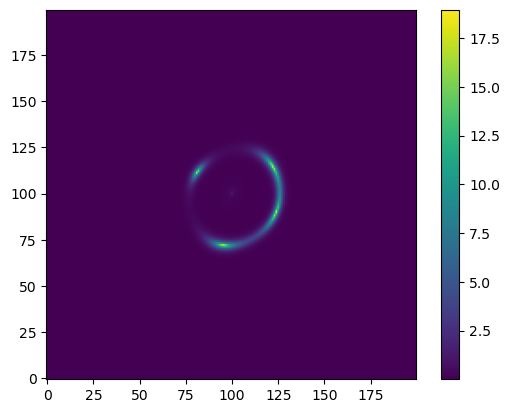

In [9]:
plt.imshow(imSim_r.image(kwargs_lens, kwargs_source_r1, kwargs_lens_light_r, kwargs_ps_multi), origin='lower')
plt.colorbar()

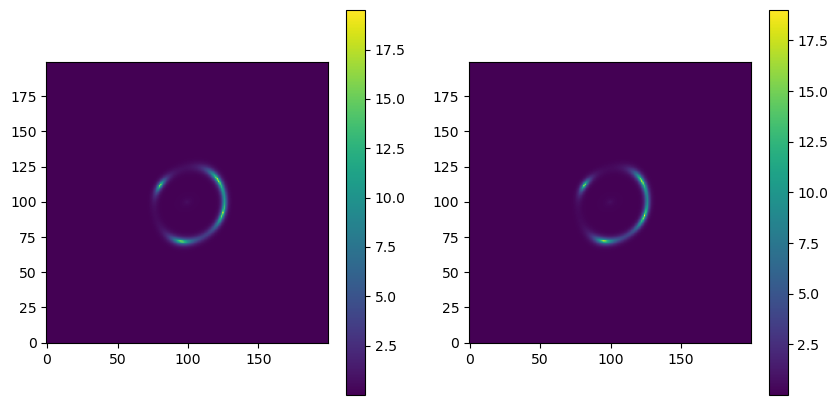

In [10]:
flux_WL = flux_WL/(np.sum(flux_ML)/np.sum(imSim_r.image(kwargs_lens, kwargs_source_r1, kwargs_lens_light_r, kwargs_ps_multi)))
flux_ML = flux_ML/(np.sum(flux_ML)/np.sum(imSim_r.image(kwargs_lens, kwargs_source_r1, kwargs_lens_light_r, kwargs_ps_multi)))
fig,ax=plt.subplots(1,2,figsize=(10,5))
ax0=ax[0].imshow(flux_WL,origin='lower')
ax1=ax[1].imshow(flux_ML,origin='lower')
fig.colorbar(ax0,ax=ax[0])
fig.colorbar(ax1,ax=ax[1])

# Add the point source

In [11]:
kwargs_r_band['seeing'] = 0.135
sim_r = SimAPI(numpix=numPix, kwargs_single_band=kwargs_r_band, kwargs_model=kwargs_model)
imSim_r = sim_r.image_model_class(kwargs_numerics)
kwargs_source_mag_r1 = [{'magnitude': 200, 'R_sersic': 0.1, 'n_sersic': 1, 
                       'e1': -0.1, 'e2': 0.1, 
                       'center_x': source_x, 'center_y':source_y}]
# source light
kwargs_lens_light_mag_r = [{'magnitude': 200, 'R_sersic': 0.6, 'n_sersic': 2, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.025, 'center_y': 0.025}]
kwargs_ps_mag_r = [{'magnitude': 20, 'ra_source': 0.1, 'dec_source': 0}]
# turn magnitude kwargs into lenstronomy kwargs
kwargs_lens_light_r, kwargs_source_r1, kwargs_ps_r = sim_r.magnitude2amplitude(kwargs_lens_light_mag_r, kwargs_source_mag_r1, kwargs_ps_mag_r)
kwargs_ps_multi = [{'ra_image': x_multilens, 'dec_image': y_multilens, 'point_amp': abs(mag_all)*kwargs_ps_r[0]['point_amp']}]
kwargs_ps_oml = [{'ra_image': x_oml, 'dec_image': y_oml, 'point_amp': abs(mag_oml)*kwargs_ps_r[0]['point_amp']}]
ps_image_multi = imSim_r.image(kwargs_lens, kwargs_source_r1, kwargs_lens_light_r, kwargs_ps_multi)
ps_image_oml   = imSim_r.image(kwargs_lens, kwargs_source_r1, kwargs_lens_light_r, kwargs_ps_oml)

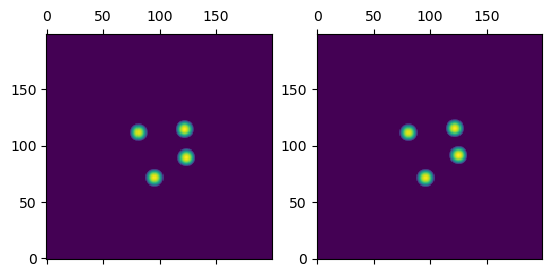

In [12]:
fig,ax = plt.subplots(1, 2)
ax[0].matshow(np.log10(ps_image_oml), origin='lower',vmin =-8)
ax[1].matshow(np.log10(ps_image_multi), origin='lower',vmin =-8)
# plt.colorbar()

# PSF and add noise

In [13]:
fwhm = 0.135
from scipy.ndimage import gaussian_filter
image_ML_psf = gaussian_filter(flux_ML, util.fwhm2sigma(fwhm)/kwargs_r_band['pixel_scale'],truncate=5.0)
image_WL_psf = gaussian_filter(flux_WL, util.fwhm2sigma(fwhm)/kwargs_r_band['pixel_scale'],truncate=5.0)

image_ML_withPS = image_ML_psf + ps_image_oml
image_WL_withPS = image_WL_psf + ps_image_multi

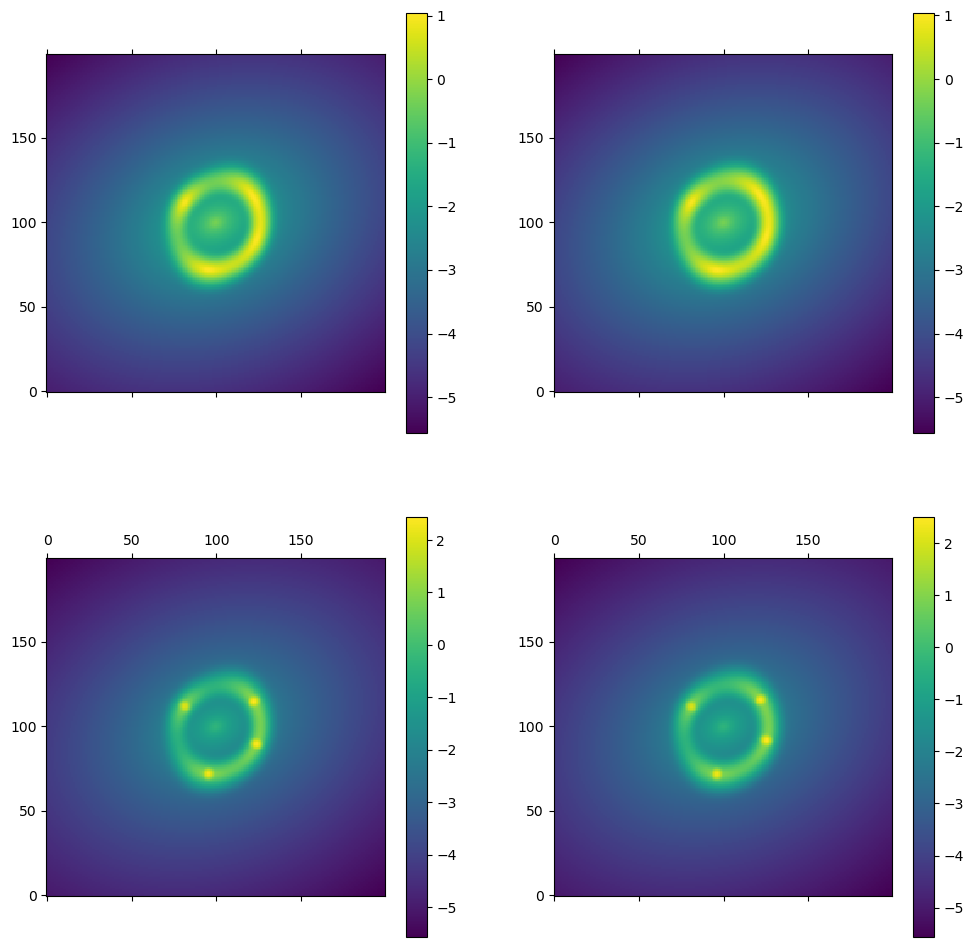

In [14]:
f, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=False)
no1=axes[0,0].matshow(np.log10(image_ML_psf), origin='lower')
f.colorbar(no1,ax=axes[0,0])

no2=axes[0,1].matshow(np.log10(image_WL_psf), origin='lower')
f.colorbar(no2,ax=axes[0,1])

no3=axes[1,0].matshow(np.log10(image_ML_withPS), origin='lower')
f.colorbar(no3,ax=axes[1,0])

no4=axes[1,1].matshow(np.log10(image_WL_withPS), origin='lower')
f.colorbar(no4,ax=axes[1,1])

In [15]:
noise_WL = sim_r.noise_for_model(model=image_WL_psf)
noise_ML = sim_r.noise_for_model(model=image_ML_psf)
image_WL_real = image_WL_psf + noise_WL
image_ML_real = image_ML_psf + noise_ML

image_WL_real_withPS = image_WL_withPS + sim_r.noise_for_model(model=image_WL_withPS)
image_ML_real_withPS = image_ML_withPS + sim_r.noise_for_model(model=image_ML_withPS)

print(np.sum(image_WL_psf)/np.sqrt(np.sum(image_WL_psf)+sim_r.background_noise*numPix**2))
print(np.sum(image_ML_psf)/np.sqrt(np.sum(image_ML_psf)+sim_r.background_noise*numPix**2))
print(np.sum(image_WL_real_withPS)/np.sqrt(np.sum(image_WL_real_withPS)+sim_r.background_noise*numPix**2))
print(np.sum(image_ML_real_withPS)/np.sqrt(np.sum(image_ML_real_withPS)+sim_r.background_noise*numPix**2))

57.462478183405764
54.444617147093275
109.28305412845233
103.1947145035106


/tmp/ipykernel_80881/2379721683.py:2: RuntimeWarning: invalid value encountered in log10
  no1=axes[0,0].matshow(np.log10(image_ML_real), origin='lower')
/tmp/ipykernel_80881/2379721683.py:5: RuntimeWarning: invalid value encountered in log10
  no2=axes[0,1].matshow(np.log10(image_WL_real), origin='lower')
/tmp/ipykernel_80881/2379721683.py:8: RuntimeWarning: invalid value encountered in log10
  no3=axes[1,0].matshow(np.log10(image_ML_real_withPS), origin='lower')
/tmp/ipykernel_80881/2379721683.py:11: RuntimeWarning: invalid value encountered in log10
  no4=axes[1,1].matshow(np.log10(image_WL_real_withPS), origin='lower')


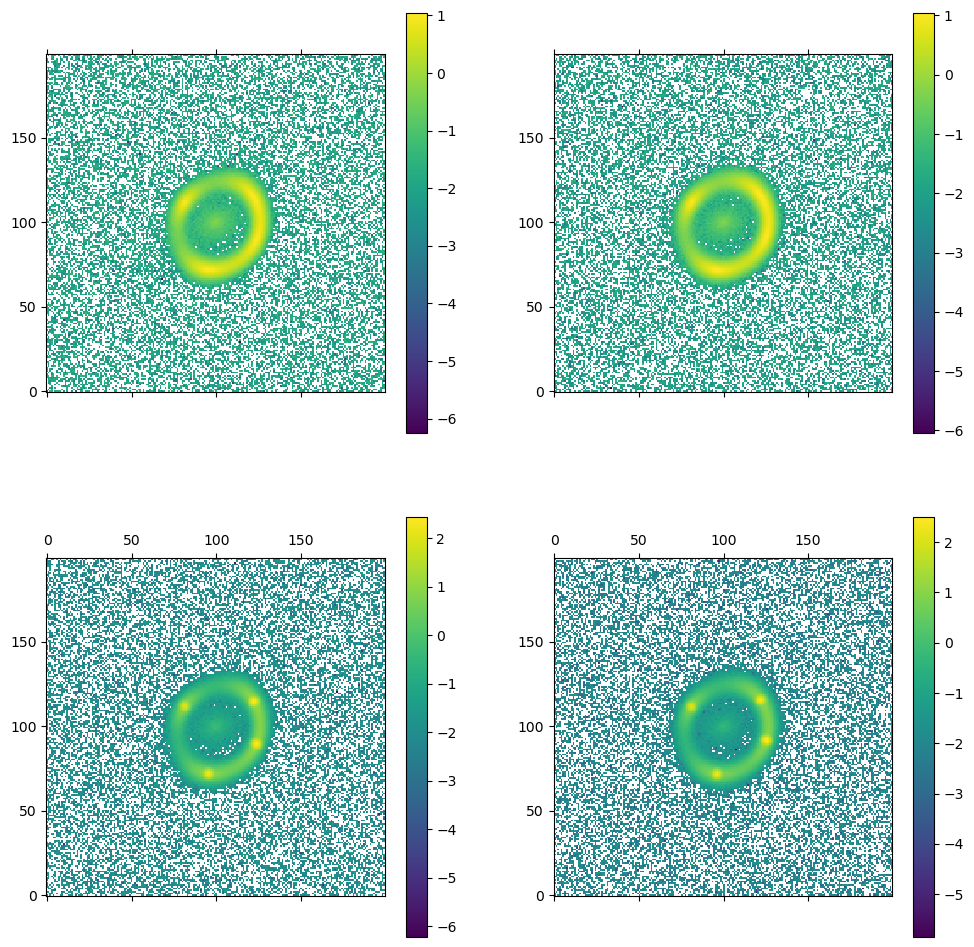

In [16]:
f, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=False)
no1=axes[0,0].matshow(np.log10(image_ML_real), origin='lower')
f.colorbar(no1,ax=axes[0,0])

no2=axes[0,1].matshow(np.log10(image_WL_real), origin='lower')
f.colorbar(no2,ax=axes[0,1])

no3=axes[1,0].matshow(np.log10(image_ML_real_withPS), origin='lower')
f.colorbar(no3,ax=axes[1,0])

no4=axes[1,1].matshow(np.log10(image_WL_real_withPS), origin='lower')
f.colorbar(no4,ax=axes[1,1])

In [17]:
# only use the middle part of the image
numPix = len(image_WL_real)
image_WL_real = image_WL_real[int(numPix/5):int(numPix*4/5),int(numPix/5):int(numPix*4/5)]
image_ML_real = image_ML_real[int(numPix/5):int(numPix*4/5),int(numPix/5):int(numPix*4/5)]
image_WL_real_withPS = image_WL_real_withPS[int(numPix/5):int(numPix*4/5),int(numPix/5):int(numPix*4/5)]
image_ML_real_withPS = image_ML_real_withPS[int(numPix/5):int(numPix*4/5),int(numPix/5):int(numPix*4/5)]

In [18]:
np.savez('/huawei/osv1/linshijie_BNU/PAPER1/data/image_rays/case{:04}/RealData'.format(case),image_ML=image_ML_real,image_WL=image_WL_real,imagePS_ML=image_ML_real_withPS,imagePS_WL=image_WL_real_withPS)